In [76]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

# **Laboratorio 1.3, Física computacional 1**

Juan Esteban Garces Duran

C.C 1077225154

# **Ejercicio 1**

In [77]:
def Laplace2D_tol(V_ini,iter_max,tol):      #Como argumento tenemos ahora la tolerancia que queramos
  Nmax=V_ini.shape[0]                       #Ademas tenemos un numero maximo de iteraciones, en caso
  V=V_ini.copy()                            #de no alcanzar la condición de parada.

  for iter in range(iter_max):
    V_viejo=V.copy()
    for i in range(1, Nmax-1):
      for j in range(1,Nmax-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])

    diff = np.max(np.abs(V-V_viejo))       #Condición de parada.
    if diff<=tol:
      break

  return V, iter

In [78]:
def grid(V_ini,x,y):
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y]
  return X,Y,Z

In [79]:
V_ini = np.zeros((100, 100), float)  #Voltaje inicial con las condiciones de frontera dadas.
for k in range(0, 100):              #Supondremos un cuadrado de 100x100 unidades.
  V_ini[k,0] = 100.0

#Hacemos la malla para graficar.
x = np.arange(0, 99, 1)
y = x

V, iter=Laplace2D_tol(V_ini, 10000, 1e-3) #Definimos como numero maximo de iteraciones 10000, y una tolerancia de 10^-3
X,Y,Z = grid(V,x,y)

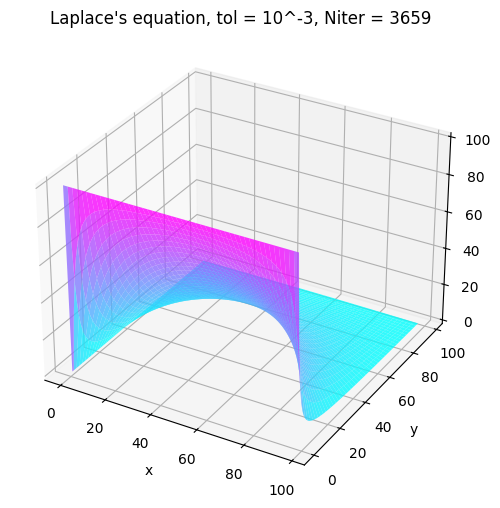

In [80]:
#Graficamos de manera analoga a como lo hace el profesor.
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title(f"Laplace's equation, tol = 10^-3, Niter = {iter}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

La solución analítica es la siguiente:

$$
u(x,y) = \sum_{\substack{n=1 \\ n\ \text{impar}}}^{\infty}
\frac{4V_0}{n\pi}
\sin\left(\frac{n\pi x}{L}\right)
\frac{\sinh\left(\frac{n\pi (L - y)}{L}\right)}{\sinh(n\pi)}
$$

Hacemos la funcion analítia:

In [81]:
x=np.linspace(0,1,100)
y=x

X,Y=np.meshgrid(x,y)      #Realizamos la malla

u=np.zeros((100,100))
tol=1e-3

u0=u.copy()
u1=u.copy()
n=1
iteracion=0
while True:
  u1+=(4*100)/(n*np.pi)*np.sin(n*np.pi*X)*(np.sinh(n*np.pi*(1-Y))/np.sinh(n*np.pi))
  iteracion+=1
  if np.max(np.abs(u1-u0))<=tol:
    break
  u0=u1.copy()
  n+=2  #n debe ser impar



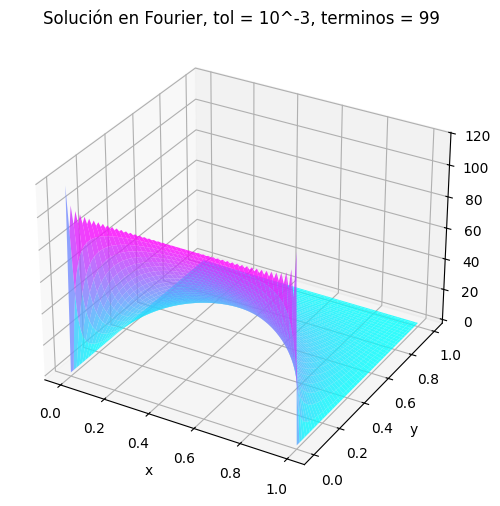

In [82]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u1, cmap='cool', alpha=0.8)
ax.set_title(f"Solución en Fourier, tol = 10^-3, terminos = {n}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

In [83]:
print(f"El numero de iteraciones para obtener la solución con una tolerancia de 10^-3 es {iteracion}")

El numero de iteraciones para obtener la solución con una tolerancia de 10^-3 es 50


Vemos que es mucho mas rapida la convergencia en la solución en terminos de Fourier.

# **Ejercicio 2**

Para las condiciones de frontera dadas, voy a hacer una particion de 100 unidades en X, y 200 en Y. Como en Y el problema no tiene una frontera definida, el valor de Y lo coloco bastante grande y asi poder simular el infinito. Usare la funcion ya definida en el ejercicio 1.

In [87]:
x=np.arange(0,101,1)
y=np.arange(0,201,2)
X,Y=np.meshgrid(x,y)

V_ini2=np.zeros((len(x),len(y)))              #Creamos el potencial con las condiciones de frontera dadas.

V_ini2[:,0]=100*np.sin(2*np.pi*x/100)
V_ini2[:,-1] = 0
V_ini2[0,:] = 0
V_ini2[-1,:] = 0

V2,iter2=Laplace2D_tol(V_ini2,10000,1e-3)     #Tolerancia de 10^-3, con un maximo de 10000 iteraciones.

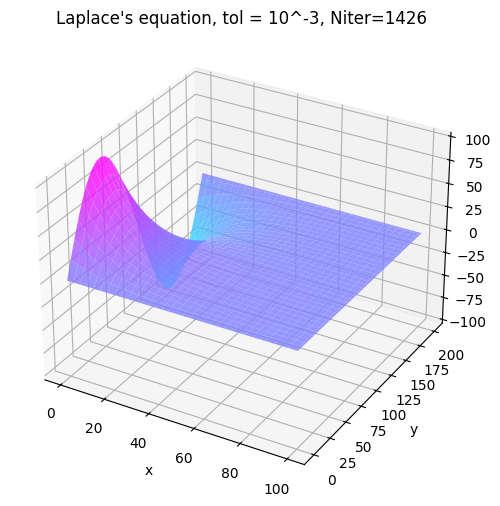

In [85]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, V2, cmap='cool', alpha=0.8)
ax.set_title(f"Laplace's equation, tol = 10^-3, Niter={iter2}")
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()